In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import numpy as np
import pandas as pd
import seaborn as sn

plt.style.use("ggplot")

# Mjøsa water temperature
# Notebook 02: Explore data

Notebook 01 generated two main outputs: `station_properties.csv` and `merged_data.csv`. These datsets have the following columns:

**station_properties.csv**

 * `station_id`: NVE station ID
 * `station_name`: NVE station name
 * `latitude`: Latitude in WGS84 decimal degrees (EPSG 4326)
 * `longitude`: Longitude in WGS84 decimal degrees (EPSG 4326)
 * `utm33_east`: Easting in UTM Zone 33N co-ordinates (EPSG 25833)
 * `utm33_north`: Northing in UTM Zone 33N co-ordinates (EPSG 25833)
 * `elevation_m`: Station elevation in  metres
 * `river_name`: River name
 * `kommune_nr`: Kommune number
 * `kommune_name`: Kommune name
 * `fylke_name`: Fylke name
 * `owner`: Organisation responsible for stations
 * `hierarchy`: Name of vassdrag
 * `regine`: REGINE catchment ID
 * `nve_area_km2`: Catchment area reported by NVE in km2
 * `cat_elev_min_m`: Minimum cathment elevation in metres
 * `cat_elev_p10_m`: 10th percentile of cathment elevation in metres
 * `cat_elev_p20_m`: 20th percentile of cathment elevation in metres
 * `cat_elev_p30_m`: 30th percentile of cathment elevation in metres
 * `cat_elev_p40_m`: 40th percentile of cathment elevation in metres
 * `cat_elev_p50_m`: 50th percentile of cathment elevation in metres
 * `cat_elev_p60_m`: 60th percentile of cathment elevation in metres
 * `cat_elev_p70_m`: 70th percentile of cathment elevation in metres
 * `cat_elev_p80_m`: 80th percentile of cathment elevation in metres
 * `cat_elev_p90_m`: 90th percentile of cathment elevation in metres
 * `cat_elev_max_m`: Maximum cathment elevation in metres
 * `regulation_type`: Type of regulation
 * `regulated_area_km2`: Area of catchment regulated in km2
 * `transfer_area_in_km2`: Various metrics indicating extent of catchment regulation that are not well defined
 * `transfer_area_out_km2`: Various metrics indicating extent of catchment regulation that are not well defined
 * `reservoir_area_in_km2`: Various metrics indicating extent of catchment regulation that are not well defined
 * `reservoir_area_out_km2`: Various metrics indicating extent of catchment regulation that are not well defined
 * `reservoir_vol_in_??`: Various metrics indicating extent of catchment regulation that are not well defined
 * `reservoir_vol_out_??`: Various metrics indicating extent of catchment regulation that are not well defined
 * `unregulated_area_km2`: Area of catchment not regulated in km2
 * `cat_area_km2`: Catchment area calculated for this analysis (in km2)
 * `a_agri_km2`: Agricultural area in km2 based on AR50's `artype` categories
 * `a_glacier_km2`: Glacier area in km2 based on AR50's `artype` categories
 * `a_lake_km2`: Lake area in km2 based on AR50's `artype` categories
 * `a_other_km2`: Other area in km2 based on AR50's `artype` categories
 * `a_sea_km2`: Sea area in km2 based on AR50's `artype` categories
 * `a_upland_km2`: Upland area in km2 based on AR50's `artype` categories
 * `a_urban_km2`: Urban area in km2 based on AR50's `artype` categories
 * `a_wood_km2`: Forest area in km2 based on AR50's `artype` categories
 * `a_agri_pct`: Proportion of agricultural land in catchment (%) based on AR50
 * `a_glacier_pct`: Proportion of glacier in catchment (%) based on AR50
 * `a_lake_pct`: Proportion of lake in catchment (%) based on AR50
 * `a_sea_pct`: Proportion of sea in catchment (%) based on AR50
 * `a_upland_pct`: Proportion of upland in catchment (%) based on AR50
 * `a_urban_pct`: Proportion of urban land in catchment (%) based on AR50
 * `a_wood_pct`: Proportion of forest in catchment (%) based on AR50
 * `a_other_pct`: Proportion of other land in catchment (%) based on AR50

**merged_data.csv**

 * `station_id`: NVE station ID
 * `station_name`: NVE station name
 * `date`: Date (in range 01.01.1990 to 31.12.2025)
 * `water_temp_c`: Water temperature measured by NVE in degrees C
 * `discharge_m3ps`: Discharge measured by NVE in m3/s
 * `gts_avg_gwb_q_mm`: Mean catchment runoff in mm modelled by NVE (via GTS API)
 * `gts_avg_qtt_mm`: Mean catchment snow melt in mm modelled by NVE (via GTS API)
 * `gts_avg_rr_mm`: Mean catchment rainfall in mm modelled by NVE (via GTS API)
 * `gts_avg_tm_c`: Mean catchment air temperature in degrees C modelled by NVE (via GTS API)
 * `gts_mod_discharge_m3ps`: Modelled discharge for the catchment outlet calculated from mean modelled runoff (`gts_avg_gwb_q_mm`) and catchment area i.e. ignoring flow routing.

Note that the model used for the GTS API does not include flow routing or any representation of water transfers (regulation etc.). Discharge simulations are therefore poor in many places, although they still capture the dominant temporal patterns.

## 1. Read data

In [2]:
# Read data
csv_path = r"/home/jovyan/shared/common/JES/mjosa_water_temp/station_properties.csv"
stn_df = pd.read_csv(csv_path)
csv_path = r"/home/jovyan/shared/common/JES/mjosa_water_temp/merged_data.csv"
df = pd.read_csv(csv_path)

print(
    f"Data available for {len(stn_df)} stations ({len(df) / 1e6} million records in total)."
)

Data available for 527 stations (3.285879 million records in total).


## 2. Clean and filter data

There are some weird values in the raw data, especially during the winter. The code below filters the data to just the sommer half of the year (April to September inclusive) and removes the most extreme outliers. **More thorough cleaning would be a good idea!**

In [3]:
# Calculate date-related features
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M")
df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)

# Convert snow melt to m3/s (similar to converting runoff => modelled discharge
df = pd.merge(df, stn_df[["station_id", "cat_area_km2"]], how="left", on="station_id")
df["gts_mod_snowmelt_m3ps"] = (
    1e6 * df["cat_area_km2"] * df["gts_avg_qtt_mm"] / (1000 * 24 * 60 * 60)
)
del df["cat_area_km2"]

# Filter to sommerhalvåret
df = df.query("(4 <= month <= 9)")

# Remove outliers
df.loc[(df["water_temp_c"] < -10) | (df["water_temp_c"] > 30), "water_temp_c"] = np.nan
df.loc[(df["discharge_m3ps"] < 0) | (df["discharge_m3ps"] > 5000), "discharge_m3ps"] = (
    np.nan
)

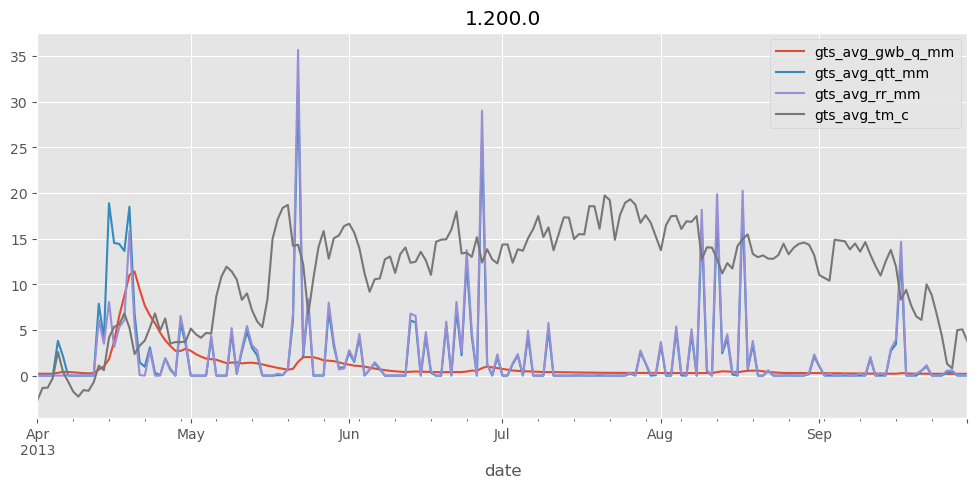

In [4]:
# Plot GTS API data for one year from one station
stn_id = "1.200.0"
year = 2013
ex_df = df.query(
    f"(station_id == @stn_id) and ('{year}-01-01' <= date <= '{year}-12-31')"
)[
    ["date", "gts_avg_gwb_q_mm", "gts_avg_qtt_mm", "gts_avg_rr_mm", "gts_avg_tm_c"]
].set_index(
    "date"
)
ax = ex_df.plot(figsize=(12, 5))
ax.set_title(stn_id);

## 3. Simple statistical model

As a (very) simple start, trying predicting the long-term mean monthly water temperature based on long-term mean climate, hydrology and glacier proportions.

In [5]:
# Long-term monthly averages
mon_df = df.groupby(["station_id", "station_name", "month"], as_index=False).mean(
    numeric_only=True
)
mon_df = pd.merge(
    mon_df, stn_df[["station_id", "a_glacier_pct"]], how="left", on="station_id"
)
print(len(mon_df))
mon_df.head()

3132


,station_id,station_name,month,water_temp_c,discharge_m3ps,gts_avg_gwb_q_mm,gts_avg_qtt_mm,gts_avg_rr_mm,gts_avg_tm_c,gts_mod_discharge_m3ps,year,sin_month,cos_month,gts_mod_snowmelt_m3ps,a_glacier_pct
0,1.200.0,Lierelv,4,4.756181,2.903267,2.593712,2.394992,1.595568,4.073633,4.019444,2018.0,8.660254e-01,-0.500000,3.711491,0.0
1,1.200.0,Lierelv,5,11.471945,1.495112,1.081189,1.746096,1.962417,9.840371,1.675506,2018.0,5.000000e-01,-0.866025,2.705905,0.0
2,1.200.0,Lierelv,6,16.305869,0.886456,0.530087,2.105878,2.329923,14.212884,0.821470,2018.0,1.224647e-16,-1.000000,3.263454,0.0
3,1.200.0,Lierelv,7,17.731425,0.678629,0.452417,2.421147,2.670789,15.869344,0.701105,2018.0,-5.000000e-01,-0.866025,3.752023,0.0
4,1.200.0,Lierelv,8,16.167402,0.979085,0.586787,2.660215,2.949472,14.250452,0.909336,2018.0,-8.660254e-01,-0.500000,4.122504,0.0


,station_id,station_name,month,water_temp_c,discharge_m3ps,gts_avg_gwb_q_mm,gts_avg_qtt_mm,gts_avg_rr_mm,gts_avg_tm_c,gts_mod_discharge_m3ps,year,sin_month,cos_month,gts_mod_snowmelt_m3ps,a_glacier_pct
0,1.200.0,Lierelv,4,4.756181,2.903267,2.593712,2.394992,1.595568,4.073633,4.019444,2018.00000,8.660254e-01,-5.000000e-01,3.711491,0.000000
1,1.200.0,Lierelv,5,11.471945,1.495112,1.081189,1.746096,1.962417,9.840371,1.675506,2018.00000,5.000000e-01,-8.660254e-01,2.705905,0.000000
2,1.200.0,Lierelv,6,16.305869,0.886456,0.530087,2.105878,2.329923,14.212884,0.821470,2018.00000,1.224647e-16,-1.000000e+00,3.263454,0.000000
3,1.200.0,Lierelv,7,17.731425,0.678629,0.452417,2.421147,2.670789,15.869344,0.701105,2018.00000,-5.000000e-01,-8.660254e-01,3.752023,0.000000
4,1.200.0,Lierelv,8,16.167402,0.979085,0.586787,2.660215,2.949472,14.250452,0.909336,2018.00000,-8.660254e-01,-5.000000e-01,4.122504,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1364,98.4.0,Øye ndf.,5,5.526536,14.145915,8.504456,10.795710,2.763280,3.309366,13.661400,2022.00000,5.000000e-01,-8.660254e-01,17.342029,3.533355
1365,98.4.0,Øye ndf.,6,8.282939,22.029265,16.278037,18.444159,2.303505,8.550349,26.148737,2022.00000,1.224647e-16,-1.000000e+00,29.628355,3.533355
1366,98.4.0,Øye ndf.,7,11.671969,12.374687,17.954441,15.436230,3.568806,10.261108,28.841681,2022.00000,-5.000000e-01,-8.660254e-01,24.796474,3.533355
1367,98.4.0,Øye ndf.,8,11.897524,10.419771,14.773053,12.512467,4.452538,9.500677,23.731158,2021.96347,-8.660254e-01,-5.000000e-01,20.099795,3.533355


Regression results for the model with the lowest AIC:

                            OLS Regression Results                            
Dep. Variable:           water_temp_c   R-squared:                       0.819
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     1025.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:11:48   Log-Likelihood:                -2966.3
No. Observations:                1369   AIC:                             5947.
Df Residuals:                    1362   BIC:                             5983.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7ece65fa04d0>,
 StandardScaler())

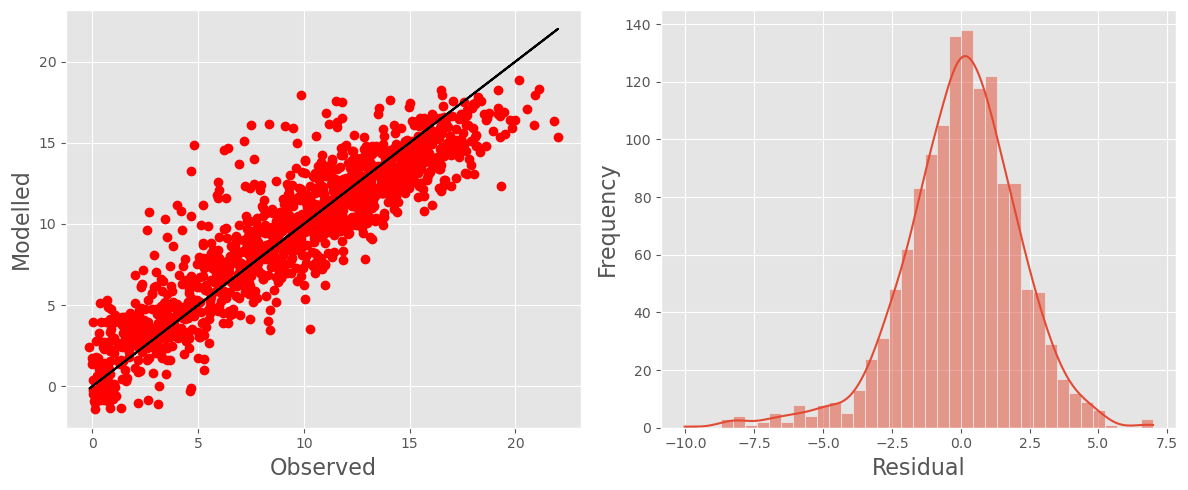

In [6]:
# Best subsets OLS regression
X = [
    "discharge_m3ps",
    "gts_avg_gwb_q_mm",
    "gts_avg_qtt_mm",
    "gts_avg_rr_mm",
    "gts_avg_tm_c",
    "a_glacier_pct",
]
y = "water_temp_c"
all_vars = [y] + X
data = mon_df.dropna(subset=all_vars).reset_index(drop=True)
display(data)
nivapy.stats.best_subsets_ols_regression(data, y, X, standardise=True)

The results above show a very simple model for **long-term monthly temperatures during the sommerhalvåret**. Using standardised variables, the adjusted $R^2$ is $82 \%$. The following variables are all significant ($p < 0.05$) and relationships seem physically plausible:

 * `gts_avg_tm_c`. **Mean air temperature**. Large positive coefficient (4.2). High air temperatures are associated with high water temperatures. The effect is large.
 * `gts_avg_qtt_mm`. **Mean monthly snow melting (*I think*)**. Large negative coefficient (-1.2). More snow melt is associated with lower water temperatures. The effect is large. 
 * `gts_avg_rr_mm`. **Mean monthly rainfall**. Medium positive coefficient (0.8). Higher rainfall is associated with higher water temperatures.
 * `discharge_m3ps`. **Mean monthly discharge**. Small positive coefficient (0.2). Higher flows are associated with higher water temperatures. The effect is small.
 * `gts_avg_gwb_q_mm`. **Mean monthly runoff**. Small positive coefficient (0.2). Higher runoff is associated with higher water temperatures. The effect is small.
 * `a_glacier_pct`. **Percent glacier cover**. Small negative coefficient (-0.2). A higher proportion of glaciers is associated with lower water temperatures. The effect is small.